In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [9]:
cols = [
'Glucose',
'BloodPressure',
'SkinThickness',
'Insulin',
'BMI'
]
for col in cols:
    df[col] = df[col].replace(0,np.nan)

In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [11]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Missing Value Treatment

Several clinical variables contained medically impossible values (0),
which were treated as missing values and replaced with NaN.

The affected variables were:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

Missing values were imputed using the median of each feature because
median is robust to outliers commonly observed in healthcare datasets.

In [13]:
df.to_csv(
    "../outputs/diabetes_cleaned.csv",
    index=False
)

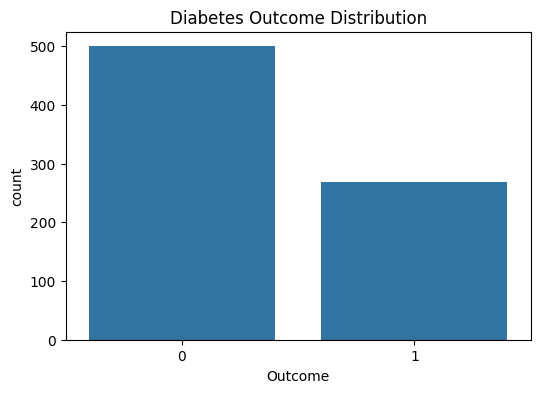

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Outcome',
    data=df
)

plt.title("Diabetes Outcome Distribution")

plt.show()

In [15]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [16]:
df['Outcome'].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

#### The dataset consisted of 768 patients, of which 34.9% were diabetic and 65.1% were non-diabetic. The class distribution is moderately imbalanced but suitable for binary classification modelling.

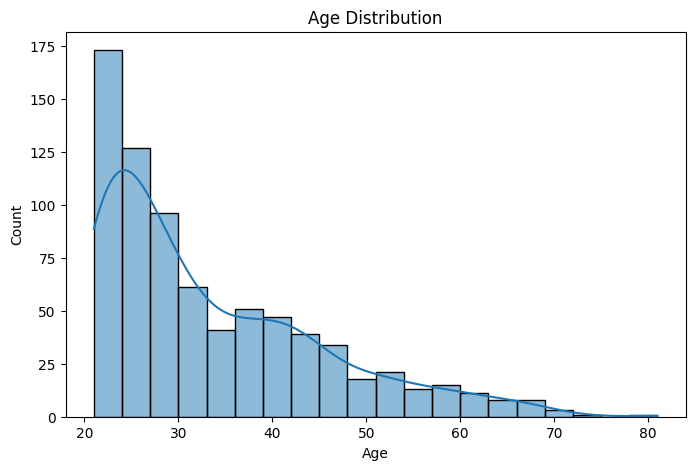

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

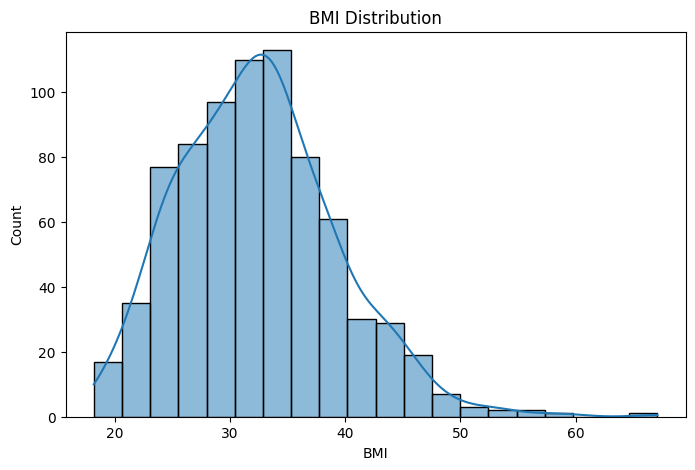

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['BMI'],
    bins=20,
    kde=True
)

plt.title("BMI Distribution")

plt.show()

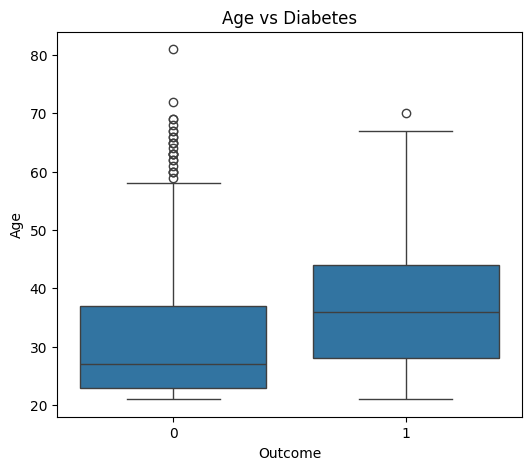

In [19]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Outcome',
    y='Age',
    data=df
)

plt.title("Age vs Diabetes")

plt.show()

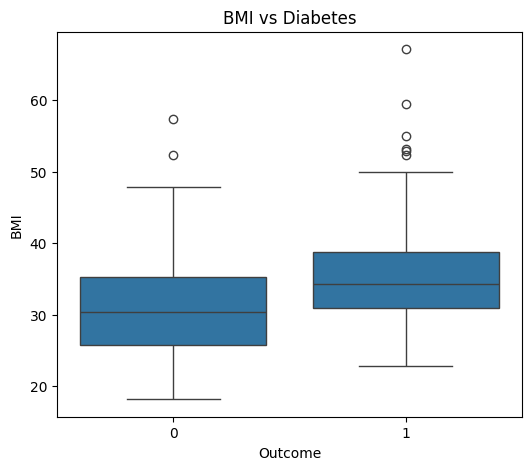

In [20]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.title("BMI vs Diabetes")

plt.show()

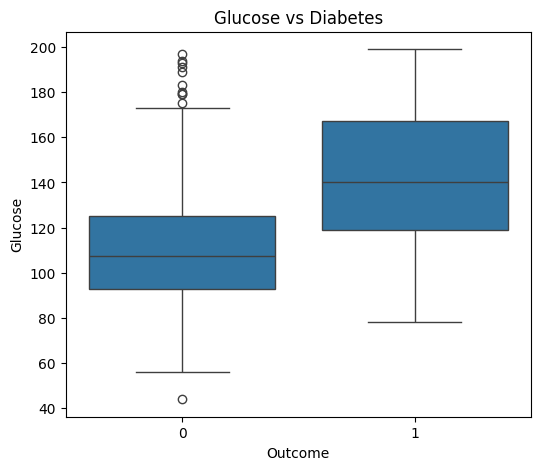

In [21]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title("Glucose vs Diabetes")

plt.show()

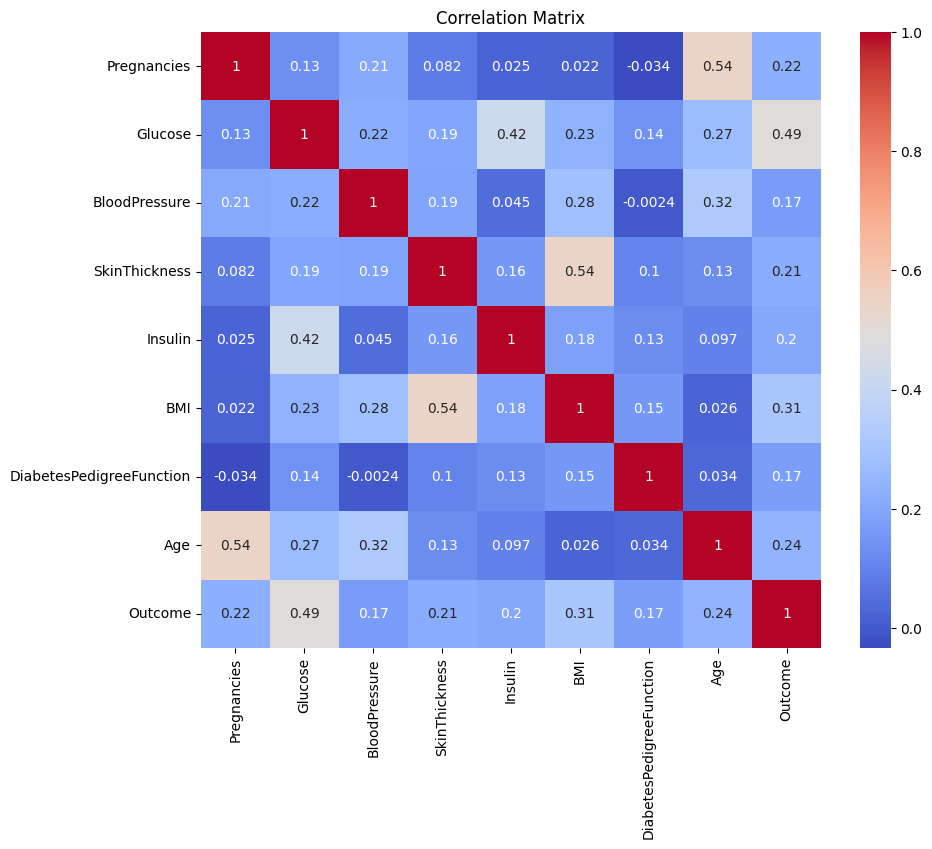

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## Key Findings

- 34.9% of patients were diabetic.
- The dataset was dominated by adults aged 20–40 years.
- Diabetic patients tended to be older than non-diabetic patients.
- Higher BMI was associated with increased diabetes prevalence.
- Glucose level demonstrated the strongest relationship with diabetes outcome.
- Correlation analysis identified Glucose (0.49), BMI (0.31), and Age (0.24) as the most influential variables.
- Obesity and elevated glucose levels emerged as major risk indicators for diabetes.

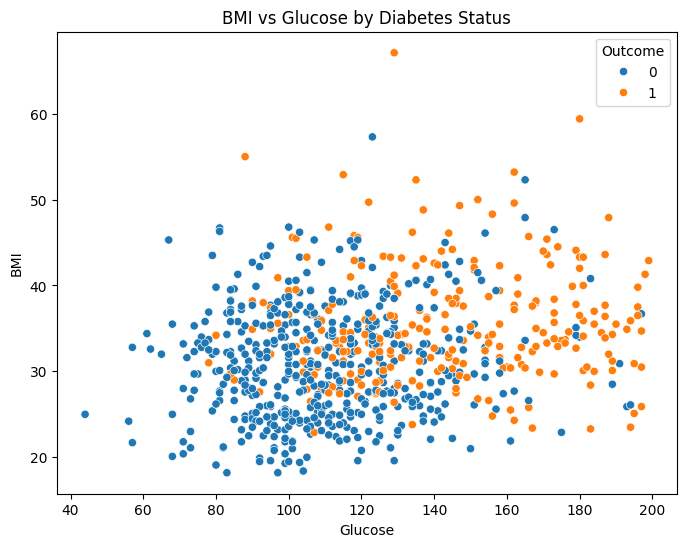

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='Outcome'
)

plt.title("BMI vs Glucose by Diabetes Status")

plt.show()

### BMI vs Glucose Analysis

A scatter plot of BMI and Glucose levels revealed substantial overlap between diabetic and non-diabetic patients. However, diabetic patients were more concentrated in regions with elevated glucose levels. This suggests that glucose is a stronger discriminator than BMI, while the combination of both variables improves patient risk stratification.

In [24]:
df['BMI_Category'] = pd.cut(
df['BMI'],
bins=[0,25,30,100],
labels=[
'Normal',
'Overweight',
'Obese'
]
)

In [25]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

In [26]:
print(X.shape)
print(y.shape)

(768, 9)
(768,)


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)

(614, 9)
(154, 9)


In [30]:
df['BMI_Category'].value_counts()

BMI_Category
Obese         476
Overweight    180
Normal        112
Name: count, dtype: int64

In [31]:
df_encoded = pd.get_dummies(
    df,
    columns=['BMI_Category'],
    drop_first=True
)

In [32]:
df_encoded.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome',
       'BMI_Category_Overweight', 'BMI_Category_Obese'],
      dtype='str')

In [33]:
X = df_encoded.drop('Outcome', axis=1)

y = df_encoded['Outcome']

In [34]:
print(X.shape)

(768, 10)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [37]:
print(X.shape)

print(X.columns)

(768, 10)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category_Overweight',
       'BMI_Category_Obese'],
      dtype='str')


In [38]:
from sklearn.linear_model import LogisticRegression

In [59]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [60]:
model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [61]:
y_pred = model.predict(
    X_test_scaled
)

In [62]:
y_prob = model.predict_proba(
    X_test_scaled
)

In [63]:
print(y_prob[:5])

[[0.67676844 0.32323156]
 [0.81433866 0.18566134]
 [0.85398056 0.14601944]
 [0.93305468 0.06694532]
 [0.58475129 0.41524871]]


In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.7597402597402597


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 17]
 [20 35]]


In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67      0.64      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



In [67]:
model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42
)

In [69]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.75609756 0.78861789 0.7398374  0.71544715 0.79508197]
Average CV Score: 0.759016393442623


In [70]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob[:,1]
)

print("ROC-AUC =", auc)

ROC-AUC = 0.819283746556474


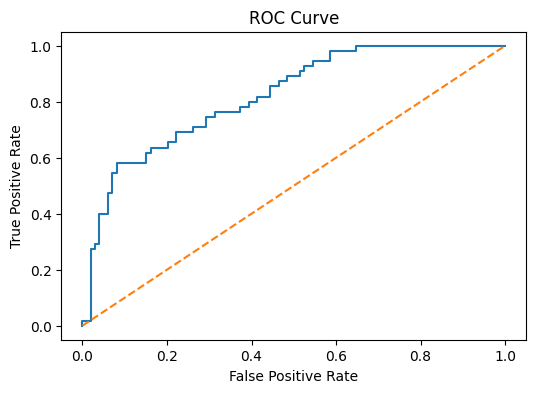

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob[:,1]
)

plt.figure(figsize=(6,4))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [72]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [73]:
print(model)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)


In [58]:
hasattr(model, 'coef_')

False

In [74]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [75]:
model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [76]:
print(model.coef_.shape)

(1, 10)


In [78]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance['Abs_Coefficient'] = importance['Coefficient'].abs()

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print(importance)

                    Feature  Coefficient  Abs_Coefficient
1                   Glucose     1.098189         1.098189
9        BMI_Category_Obese     0.773621         0.773621
7                       Age     0.434556         0.434556
8   BMI_Category_Overweight     0.402502         0.402502
5                       BMI     0.370808         0.370808
6  DiabetesPedigreeFunction     0.216930         0.216930
0               Pregnancies     0.188426         0.188426
4                   Insulin    -0.156238         0.156238
2             BloodPressure    -0.148378         0.148378
3             SkinThickness     0.058679         0.058679


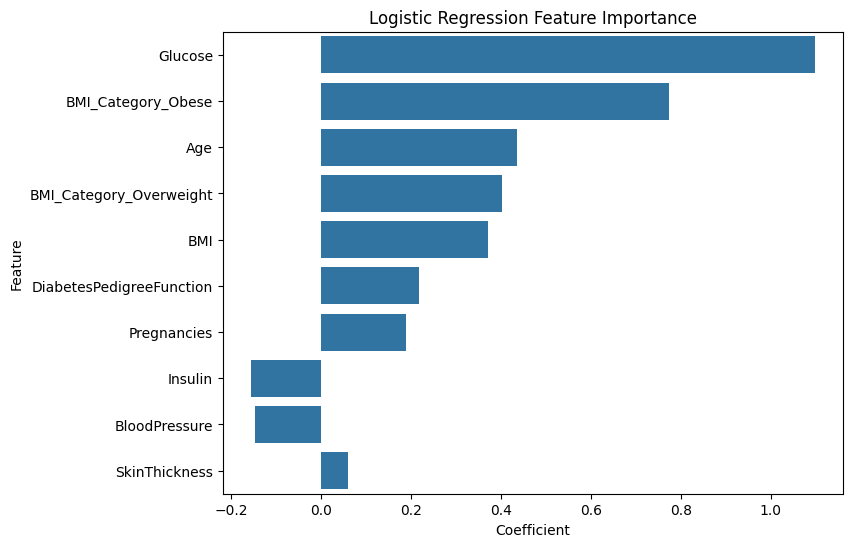

In [79]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Logistic Regression Feature Importance")

plt.show()

## Key Risk Factors Identified

Feature importance analysis using Logistic Regression identified:

1. Glucose as the strongest predictor of diabetes.
2. Obesity status as a major risk factor.
3. Increasing age as a significant contributor to diabetes risk.
4. Higher BMI values as positively associated with diabetes.
5. Family history (Diabetes Pedigree Function) as a moderate predictor.

These findings align with established clinical understanding of Type 2 Diabetes risk factors.

In [80]:
results = X_test.copy()

results['Actual_Outcome'] = y_test.values
results['Predicted_Outcome'] = y_pred
results['Diabetes_Probability'] = y_prob[:,1]

results.to_csv(
    "../outputs/diabetes_predictions.csv",
    index=False
)

In [81]:
results.to_csv(
    '../outputs/diabetes_predictions.csv',
    index=False
)

In [82]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance

,Feature,Coefficient
1,Glucose,1.098189
9,BMI_Category_Obese,0.773621
7,Age,0.434556
8,BMI_Category_Overweight,0.402502
5,BMI,0.370808
6,DiabetesPedigreeFunction,0.216930
0,Pregnancies,0.188426
3,SkinThickness,0.058679
2,BloodPressure,-0.148378
4,Insulin,-0.156238


In [83]:
importance.to_csv(
    '../outputs/feature_importance.csv',
    index=False
)